In [60]:
# Step 0: Setup & Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [61]:
# Step 1: Load Data

print("=== Step 1: Loading Data ===")
# Ensure 'Android_Permission.csv' is in your working directory
df = pd.read_csv('Android_Permission.csv')
print(f"Initial Dataset Shape: {df.shape} (Rows x Columns)\n")
print("First 3 rows of the dataset:")
print(df.head(3))
print("\n" + "="*40)

=== Step 1: Loading Data ===
Initial Dataset Shape: (29999, 184) (Rows x Columns)

First 3 rows of the dataset:
                       App                    Package        Category  \
0  Canada Post Corporation     com.canadapost.android        Business   
1                Word Farm  com.realcasualgames.words  Brain & Puzzle   
2     Fortunes of War FREE         fortunesofwar.free  Cards & Casino   

                                         Description  Rating  \
0  Canada Post Mobile App gives you access to som...     3.1   
1  Speed and strategy combine in this exciting wo...     4.3   
2  Fortunes of War is a fast-paced, easy to learn...     4.1   

   Number of ratings  Price  \
0                 77    0.0   
1                199    0.0   
2                243    0.0   

                                        Related apps  \
0  {com.adaffix.pub.ca.android, com.kevinquan.gas...   
1  {air.com.zubawing.FastWordLite, com.joybits.do...   
2  {com.kevinquan.condado, hu.monsta.pazaak, 


=== Step 2: Data Cleaning ===
Shape after keeping only numeric columns: (22538, 157)
Dropped 0 constant/zero-variance columns. Shape is now (22538, 157)
Final Cleaned Shape (removed NAs & duplicates): (22538, 157)

[VISUALIZATION] Displaying Class Distribution Chart...


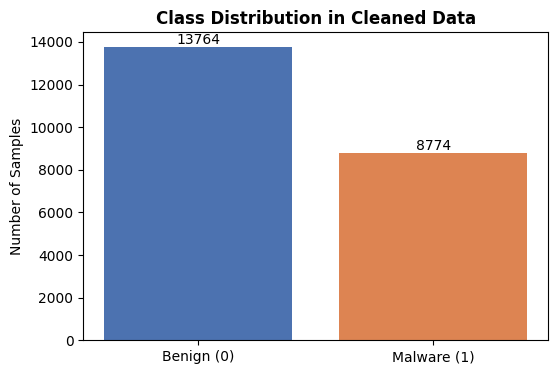

In [71]:
# Step 2: Data Cleaning
print("\n=== Step 2: Data Cleaning ===")
target_col = 'Class'

# Keep only numeric columns + target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
df = df[numeric_cols + [target_col]]
print(f"Shape after keeping only numeric columns: {df.shape}")

# Encode target as binary (0 = Benign, 1 = Malware)
unique_vals = sorted(df[target_col].dropna().unique())
if not set(unique_vals).issubset({0, 1}):
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    df[target_col] = df[target_col].map(mapping)

# Drop constant / zero-variance columns
candidate_feature_cols = [c for c in df.columns if c != target_col]
nunique = df[candidate_feature_cols].nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
df.drop(columns=constant_cols, inplace=True)
feature_cols = [c for c in df.columns if c != target_col]
print(f"Dropped {len(constant_cols)} constant/zero-variance columns. Shape is now {df.shape}")

# Handle missing values & remove duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f"Final Cleaned Shape (removed NAs & duplicates): {df.shape}")

# Visualization: Class Distribution
print("\n[VISUALIZATION] Displaying Class Distribution Chart...")
class_counts = df[target_col].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(['Benign (0)', 'Malware (1)'], class_counts.values, color=['#4C72B0', '#DD8452'])
plt.title('Class Distribution in Cleaned Data', fontweight='bold')
plt.ylabel('Number of Samples')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')
plt.show()

In [58]:

# Step 3: Train / Test Split

print("\n=== Step 3: Train / Test Split ===")
X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32)
INPUT_DIM = X.shape[1]
print(f"Total Input Features (Neurons): {INPUT_DIM}")

# Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("Features have been standardized (mean=0, std=1).")

# Compute Class Weights to handle imbalance
class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f"Computed Class Weights for training: {class_weight_dict}")


=== Step 3: Train / Test Split ===
Total Input Features (Neurons): 156
Training samples: 18030
Testing samples:  4508
Features have been standardized (mean=0, std=1).
Computed Class Weights for training: {0: np.float64(1.2843709930189486), 1: np.float64(0.8187267278176369)}



=== Step 4: Building & Training Models ===

---> Preparing ANN_Model1 with architecture: [128, 64, 32, 16, 8, 1]


Model: "ANN_Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,097 (125.38 KB)

 Trainable params: 31,601 (123.44 KB)

 Non-trainable params: 496 (1.94 KB)

Training ANN_Model1...
Training stopped after 37 epochs.
[VISUALIZATION] Displaying Training History for ANN_Model1...


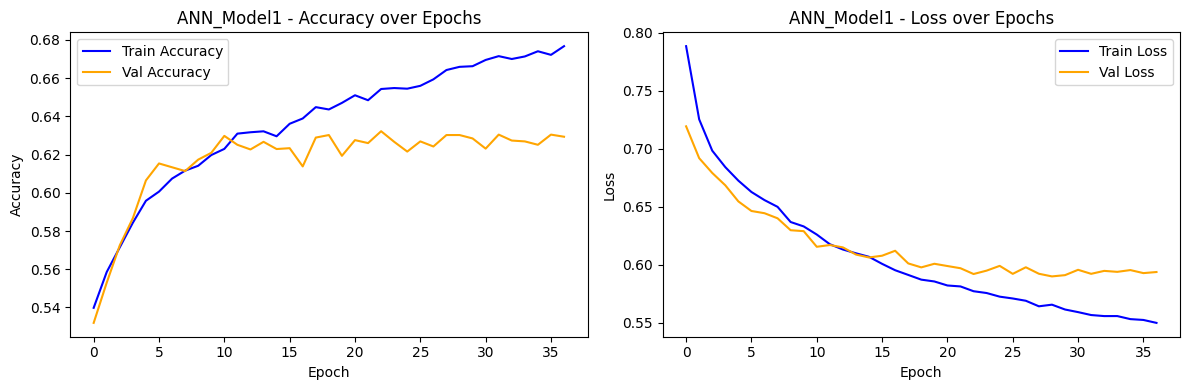


---> Preparing ANN_Model2 with architecture: [64, 32, 16, 8, 1]


Model: "ANN_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 64)             │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,281 (51.88 KB)

 Trainable params: 13,041 (50.94 KB)

 Non-trainable params: 240 (960.00 B)

Training ANN_Model2...
Training stopped after 35 epochs.
[VISUALIZATION] Displaying Training History for ANN_Model2...


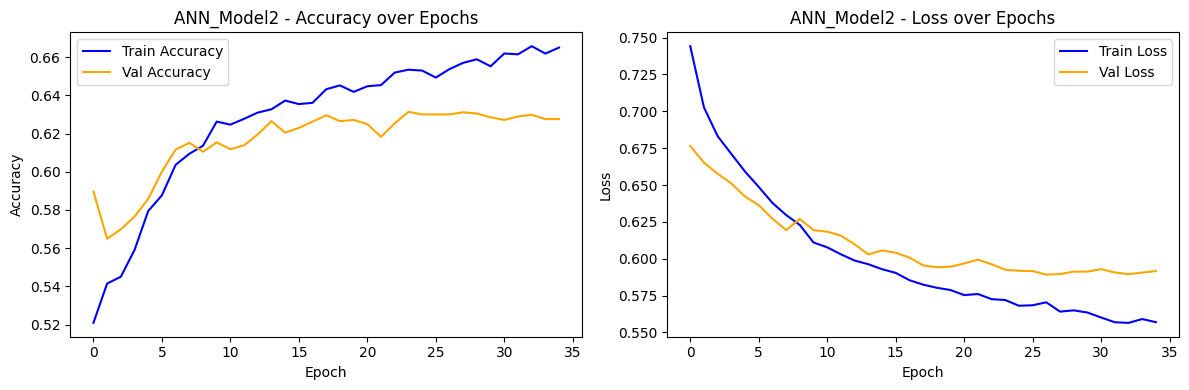


---> Preparing ANN_Model3 with architecture: [32, 16, 8, 1]


Model: "ANN_Model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 32)             │         5,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,809 (22.69 KB)

 Non-trainable params: 112 (448.00 B)

Training ANN_Model3...
Training stopped after 40 epochs.
[VISUALIZATION] Displaying Training History for ANN_Model3...


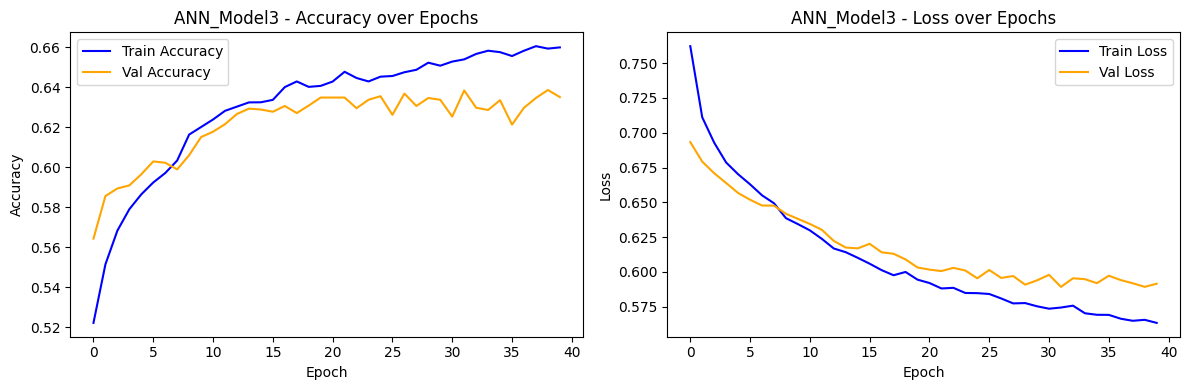


---> Preparing ANN_Model4 with architecture: [16, 8, 1]


Model: "ANN_Model4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 16)             │         2,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,705 (10.57 KB)

 Non-trainable params: 48 (192.00 B)

Training ANN_Model4...
Training stopped after 38 epochs.
[VISUALIZATION] Displaying Training History for ANN_Model4...


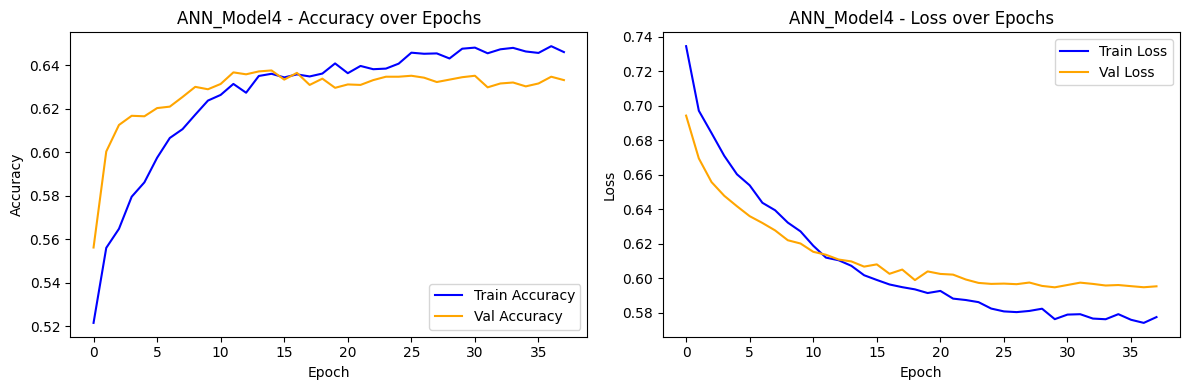

In [64]:
# Step 4: Modeling Setup & Training

print("\n=== Step 4: Building & Training Models ===")

def build_ann(input_dim, layer_units, model_name='ANN'):
    model = keras.Sequential(name=model_name)
    model.add(layers.Input(shape=(input_dim,), name='input_layer'))
    for i, units in enumerate(layer_units[:-1]):
        model.add(layers.Dense(units, activation='relu', kernel_initializer='he_normal'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))
    model.add(layers.Dense(layer_units[-1], activation='sigmoid', name='output'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_model(model, X_tr, y_tr, X_val, y_val, cw, epochs=60, batch_size=256):
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0)
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs,
                        batch_size=batch_size, class_weight=cw,
                        callbacks=[early_stop, reduce_lr], verbose=0)
    return history

def plot_history(history, model_name):
    print(f"[VISUALIZATION] Displaying Training History for {model_name}...")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Accuracy
    ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    ax[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
    ax[0].set_title(f'{model_name} - Accuracy over Epochs')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    
    # Plot Loss
    ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
    ax[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax[1].set_title(f'{model_name} - Loss over Epochs')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

# Define the 4 architectures
models_info = [
    ('ANN_Model1', [128, 64, 32, 16, 8, 1]),
    ('ANN_Model2', [64, 32, 16, 8, 1]),
    ('ANN_Model3', [32, 16, 8, 1]),
    ('ANN_Model4', [16, 8, 1])
]

trained_models = {}
for name, architecture in models_info:
    print(f"\n---> Preparing {name} with architecture: {architecture}")
    model = build_ann(INPUT_DIM, architecture, model_name=name)
    model.summary() # Prints the layer structure and parameter count
    
    print(f"Training {name}...")
    history = train_model(model, X_train, y_train, X_test, y_test, class_weight_dict)
    print(f"Training stopped after {len(history.history['loss'])} epochs.")
    
    # Plot the learning curve
    plot_history(history, name)
    trained_models[name] = model

In [69]:
# Step 5: Execution & Evaluation

# Build and train Model 4
model4 = build_ann(INPUT_DIM, [16, 8, 1], model_name='ANN_Model4')

print('Training ANN Model 4 (3 layers: 16-8-1) ...')
history4 = train_model(model4, X_train, y_train, X_test, y_test, class_weight_dict)
print('Done. Epochs run:', len(history4.history['loss']))

# Evaluate to get the specific output requested
result4 = evaluate_model(model4, X_test, y_test, 'ANN Model 4 (16-8-1)')

Training ANN Model 4 (3 layers: 16-8-1) ...
Done. Epochs run: 50



=== Step 5: Evaluation & Comparison ===

  MODEL COMPARISON - Metrics (in %)
            Accuracy  Precision  Recall  F1-Score
Model                                            
ANN_Model1     63.02      83.77   48.93     61.77
ANN_Model2     63.00      83.80   48.86     61.73
ANN_Model3     63.84      82.78   51.51     63.50
ANN_Model4     63.44      82.60   50.85     62.95

[VISUALIZATION] Displaying Confusion Matrix for Best Model (ANN_Model4)...


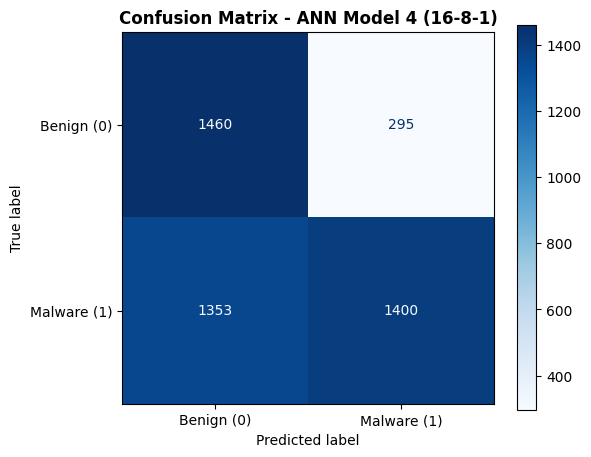

In [70]:

# Step 5: Evaluation & Comparison

print("\n=== Step 5: Evaluation & Comparison ===")
def evaluate_model(model, X_te, y_te, model_name):
    y_pred_prob = model.predict(X_te, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1-Score': f1_score(y_te, y_pred, zero_division=0),
        'y_pred': y_pred
    }

results = []
for name, _ in models_info:
    res = evaluate_model(trained_models[name], X_test, y_test, name)
    results.append(res)

# Generate Summary Table
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in results
]).set_index('Model')

print('\n=============================================================')
print('  MODEL COMPARISON - Metrics (in %)')
print('=============================================================')
print((metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']] * 100).round(2).to_string())
print('=============================================================\n')

# Best model plot (Model 4)
print("[VISUALIZATION] Displaying Confusion Matrix for Best Model (ANN_Model4)...")
best_pred = next(r['y_pred'] for r in results if r['Model'] == 'ANN_Model4')

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malware (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - ANN Model 4 (16-8-1)', fontweight='bold')
plt.show()


[VISUALIZATION] Top Correlated Features with Malware...


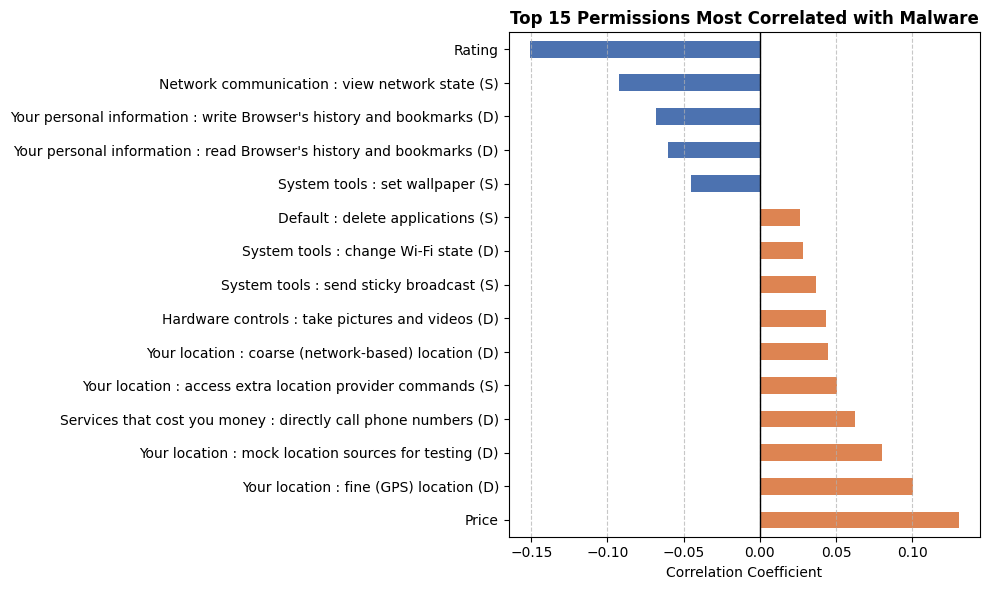

In [ ]:
# ==========================================
# EXTRA: Data Exploration Visualizations
# ==========================================
print("\n[VISUALIZATION] Top Correlated Features with Malware...")
import seaborn as sns

# 1. Feature Correlation Bar Chart
plt.figure(figsize=(10, 6))
# Calculate correlations with the target and sort them
correlations = df.corr()[target_col].drop(target_col).sort_values(ascending=False)
# Get top 10 positive and top 5 negative correlations
top_features = pd.concat([correlations.head(10), correlations.tail(5)])

# Plot
top_features.plot(kind='barh', color=np.where(top_features > 0, '#DD8452', '#4C72B0'))
plt.title('Top 15 Permissions Most Correlated with Malware', fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Boxplot: Dangerous Permissions Distribution
print("\n[VISUALIZATION] Dangerous Permissions Distribution...")
plt.figure(figsize=(6, 5))
sns.boxplot(x=target_col, y='Dangerous permissions count', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Dangerous Permissions Count: Benign vs Malware', fontweight='bold')
plt.xticks([0, 1], ['Benign (0)', 'Malware (1)'])
plt.ylabel('Count of Dangerous Permissions')
plt.tight_layout()
plt.show()